<a href="https://colab.research.google.com/github/CAUEz3108/informatica-/blob/main/red_wine_quality_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
pip install ucimlrepo

In [4]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
wine_quality = fetch_ucirepo(id=186)

# data (as pandas dataframes)
X = wine_quality.data.features
y = wine_quality.data.targets

# metadata
print(wine_quality.metadata)

# variable information
print(wine_quality.variables)


{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine preferences

In [5]:
import pandas as pd


### Displaying DataFrame X (Features)

In [7]:
display(X)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8


### Displaying DataFrame y (Targets)

In [8]:
display(y)

,quality
0,5
1,5
2,5
3,6
4,5
...,...
6492,6
6493,5
6494,6
6495,7


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Split the data into training and testing sets using the existing X and y
X_train, X_test, y_train, y_test = train_test_split(X.values, y.values, test_size=0.2, random_state=42)

# Create a Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"Modelo de Regressão Linear Treinado:")
print(f"Coeficiente (inclinação): {model.coef_[0][0]:.2f}")
print(f"Intercepto: {model.intercept_[0]:.2f}")
print(f"R-squared no conjunto de teste: {r2:.2f}")
print(f"Erro Quadrático Médio no conjunto de teste: {mse:.2f}")

Modelo de Regressão Linear Treinado:
Coeficiente (inclinação): 0.08
Intercepto: 59.42
R-squared no conjunto de teste: 0.26
Erro Quadrático Médio no conjunto de teste: 0.55


--- Linear Regression Coefficients ---


,Feature,Coefficient
0,fixed_acidity,0.078975
1,volatile_acidity,-1.350775
2,citric_acid,-0.143778
3,residual_sugar,0.045949
4,chlorides,-0.332842
5,free_sulfur_dioxide,0.007025
6,total_sulfur_dioxide,-0.002663
7,density,-58.945052
8,pH,0.482842
9,sulphates,0.808360



--- Individual Feature Scatter Plots with Regression Lines ---


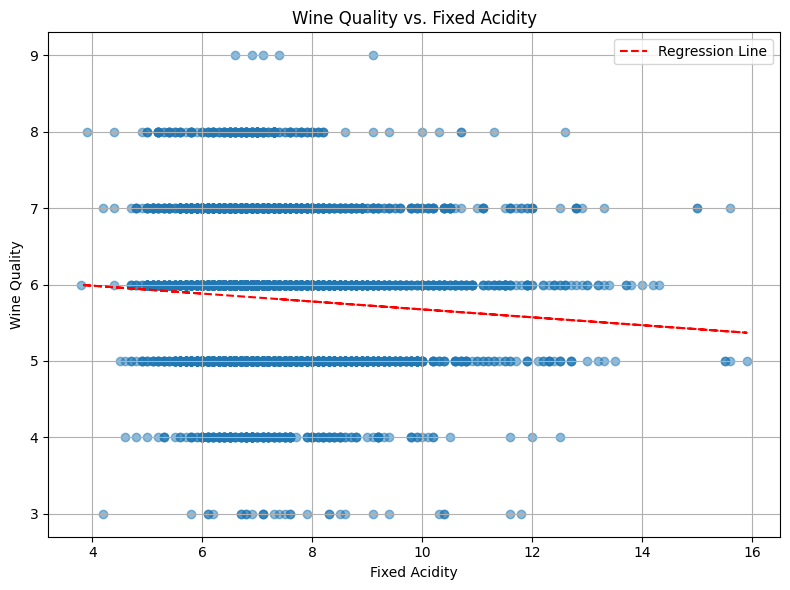

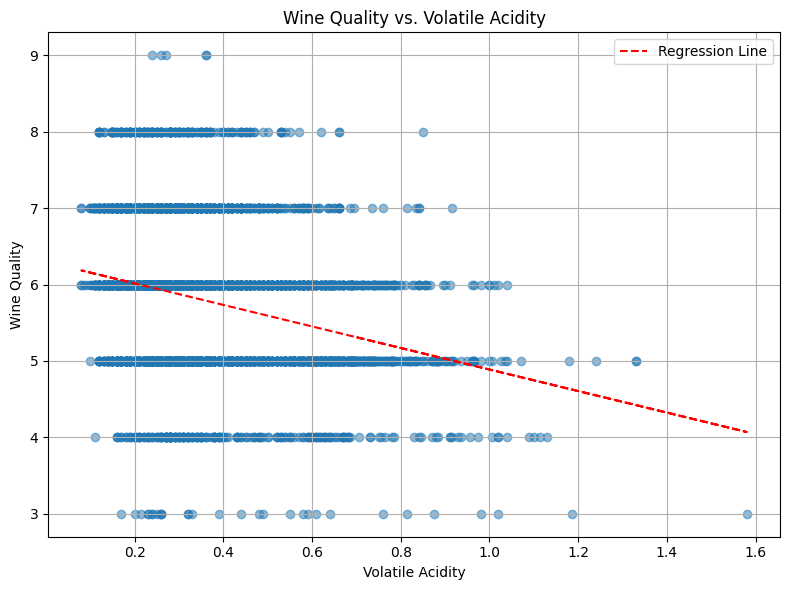

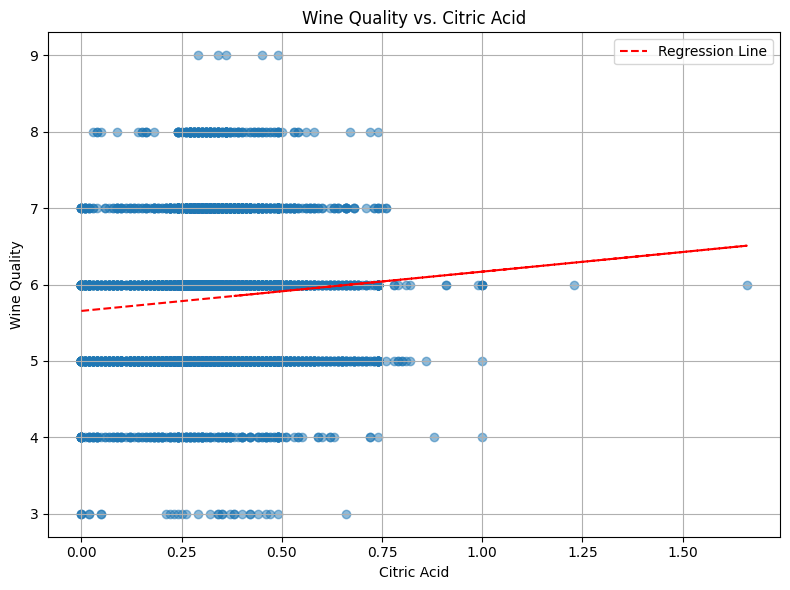

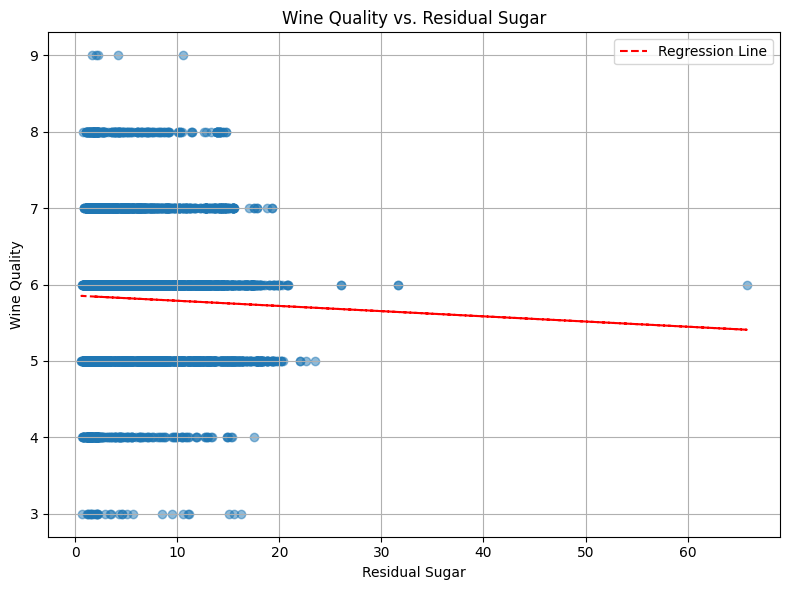

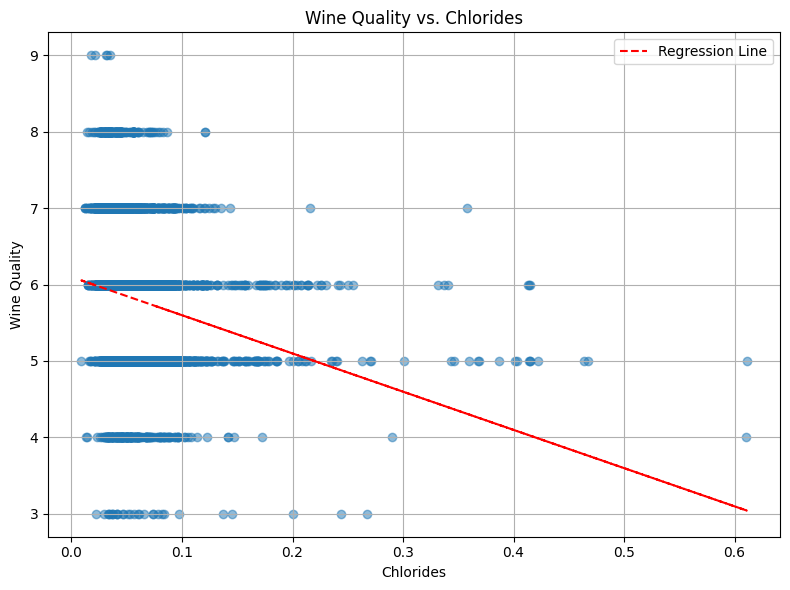

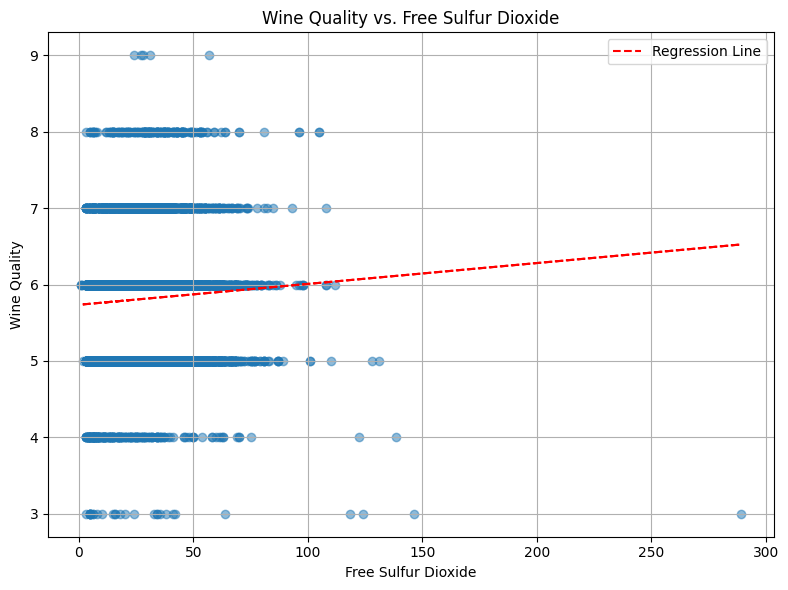

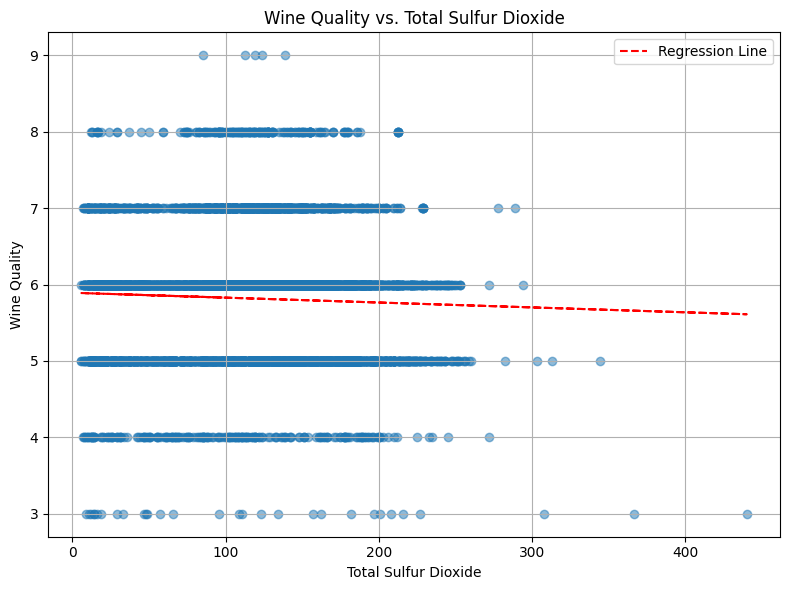

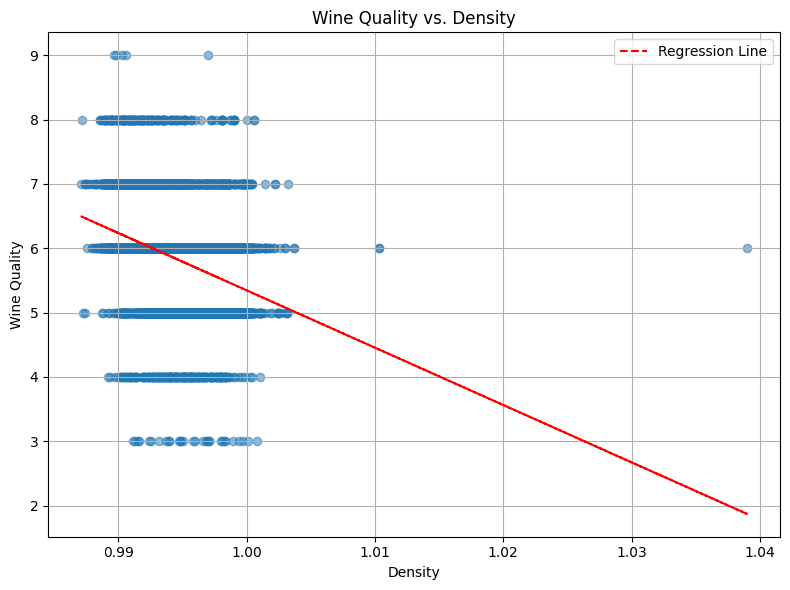

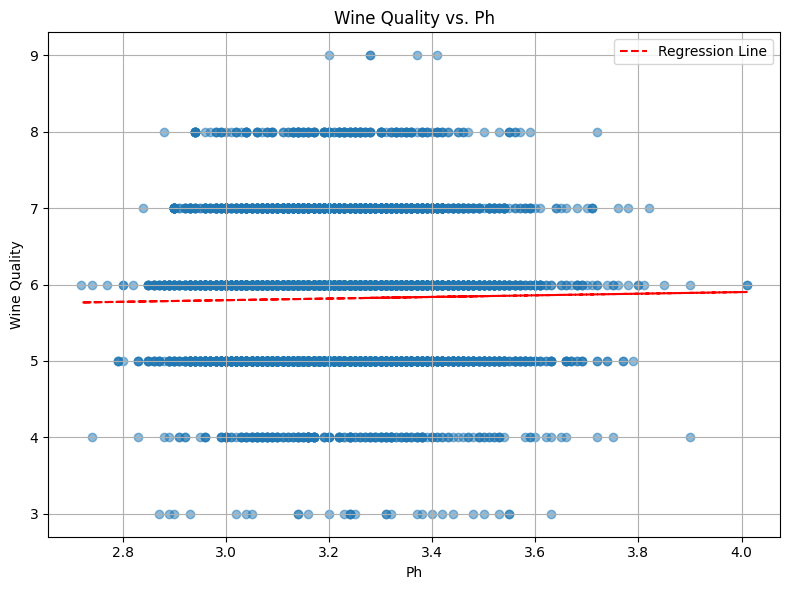

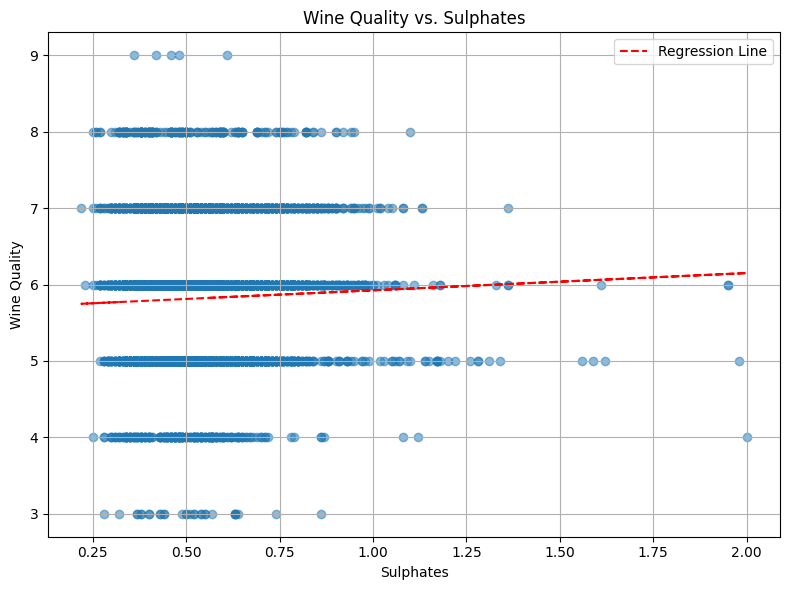

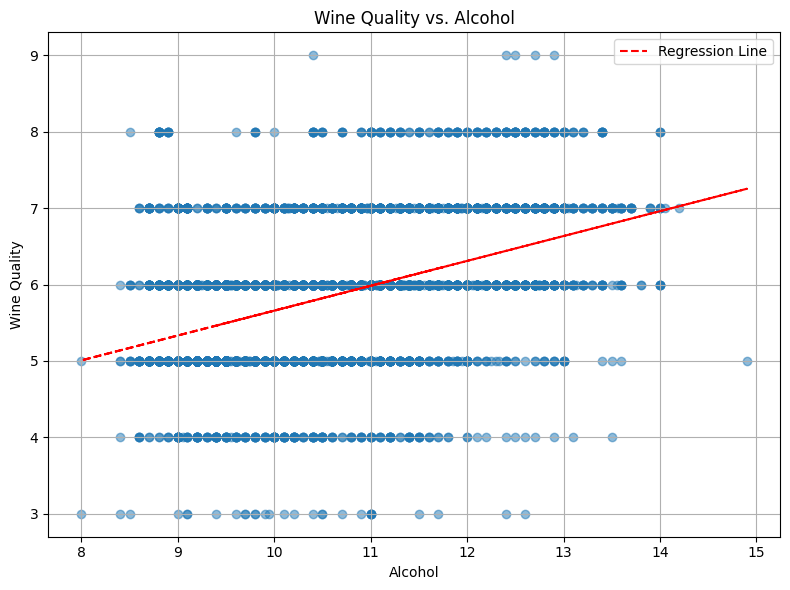

In [20]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression # Import LinearRegression
import numpy as np # Import numpy for reshaping
import pandas as pd # Import pandas for DataFrame creation

# Get feature names from X
feature_names = X.columns

# Display a table of feature coefficients from the overall model
# Assuming 'model' (the LinearRegression model trained on all features) is available from a previous cell
if 'model' in locals():
    coefficients_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': model.coef_.flatten()})
    print('--- Linear Regression Coefficients ---')
    display(coefficients_df)
else:
    print("The overall linear regression model ('model') was not found. Please ensure the cell where it's trained has been run.")

print('\n--- Individual Feature Scatter Plots with Regression Lines ---')

# Create a separate scatter plot for each feature against 'quality'
for feature in feature_names:
    plt.figure(figsize=(8, 6))
    plt.scatter(X[feature], y, alpha=0.5)

    # Fit a linear regression model for the current feature
    model_feature = LinearRegression()
    # Reshape X[feature] to a 2D array and y to a 2D array for the model
    X_feature_reshaped = X[feature].values.reshape(-1, 1)
    y_reshaped = y.values.reshape(-1, 1)

    model_feature.fit(X_feature_reshaped, y_reshaped)

    # Predict values using the fitted model
    y_pred_feature = model_feature.predict(X_feature_reshaped)

    # Plot the regression line
    plt.plot(X[feature], y_pred_feature, color='red', linestyle='--', label='Regression Line')

    plt.xlabel(feature.replace('_', ' ').title()) # Format feature name for readability
    plt.ylabel('Wine Quality')
    plt.title(f'Wine Quality vs. {feature.replace('_', ' ').title()}')
    plt.grid(True)
    plt.tight_layout()
    plt.legend() # Add legend to show regression line label
    plt.show()